# 🏆 Spot the Mask — Full Winning Solution (FIXED)
**Rank 14 → #1 pipeline**  
All bugs fixed:
- ✅ sample_submission.csv casing auto-detected
- ✅ reset_index on combined df (fixes IndexError)
- ✅ OOF size mismatch fixed in train_kfold
- ✅ optimize_weights catches size mismatch, falls back to equal weights
- ✅ run_pseudo_round uses skip_if_exists=True (resumes after crash)
- ✅ r_path variables restored automatically
- ✅ Pseudo round N just needs round_num changed

**Runtime:** Runtime → Change runtime type → T4 GPU → Save

## 📦 CELL 1 — Install & Mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
PROJECT = '/content/drive/MyDrive/spot_the_mask'
os.chdir(PROJECT)
sys.path.insert(0, PROJECT)
print('Project:', os.getcwd())

!pip install -q timm albumentations omegaconf scipy

import torch
assert torch.cuda.is_available(), '❌ No GPU! Runtime → Change runtime type → T4 GPU'
print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
print(f'✅ VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Mounted at /content/drive
Project: /content/drive/MyDrive/spot_the_mask
✅ GPU: Tesla T4
✅ VRAM: 15.6 GB


## ⚙️ CELL 2 — Imports & Config

In [3]:
import gc, cv2, time, math, inspect, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from contextlib import nullcontext

import torch
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

# ── Fix sample_submission casing automatically ─────────────
raw_dir = Path('data/raw')
_found = None
for _f in raw_dir.glob('*.csv'):
    if _f.name.lower() == 'samplesubmission.csv':
        _found = _f; break
if _found and _found.name != 'sample_submission.csv':
    shutil.copy(_found, raw_dir / 'sample_submission.csv')
    print(f'✅ Renamed {_found.name} → sample_submission.csv')

CFG = {
    'train_csv'       : 'data/raw/train_labels.csv',
    'sample_sub'      : 'data/raw/sample_submission.csv',
    'images_dir'      : 'data/raw/images',
    'model_dir'       : 'outputs/models',
    'sub_dir'         : 'outputs/submissions',
    'image_size'      : 300,
    'n_folds'         : 5,
    'num_workers'     : 4,
    'seed'            : 42,
    'epochs'          : 40,
    'batch_size'      : 32,
    'accum_steps'     : 1,
    'lr'              : 1e-4,
    'weight_decay'    : 1e-2,
    'warmup_epochs'   : 2,
    'label_smooth'    : 0.05,
    'patience'        : 8,
    'use_amp'         : True,
    'models': [
        {'name': 'efficientnet_b2', 'image_size': 300, 'dropout': 0.35},
        {'name': 'efficientnet_b4', 'image_size': 380, 'dropout': 0.40},
    ],
    'tta_steps'       : 8,
    'pseudo_threshold': 0.95,
}

Path(CFG['model_dir']).mkdir(parents=True, exist_ok=True)
Path(CFG['sub_dir']).mkdir(parents=True, exist_ok=True)
print('✅ Config loaded')

✅ Config loaded


## 🔧 CELL 3 — Helper Functions

In [4]:
def set_seed(seed=42):
    import random, os
    random.seed(seed); os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CFG['seed'])
DEVICE = torch.device('cuda')

def compute_auc(targets, preds):
    try: return float(roc_auc_score(targets, preds))
    except: return 0.5

def flush():
    gc.collect(); torch.cuda.empty_cache()

# ── Version-safe albumentations ────────────────────────────
def _rrc(sz, scale=(0.7,1.0), ratio=(0.75,1.33)):
    sig = inspect.signature(A.RandomResizedCrop.__init__).parameters
    if 'size' in sig:
        return A.RandomResizedCrop(size=(sz,sz), scale=scale, ratio=ratio, p=1.0)
    return A.RandomResizedCrop(height=sz, width=sz, scale=scale, ratio=ratio, p=1.0)

def _resize(sz):
    sig = inspect.signature(A.Resize.__init__).parameters
    if 'size' in sig: return A.Resize(size=(sz,sz))
    return A.Resize(height=sz, width=sz)

def _dropout(sz):
    hole = sz // 8
    sig = inspect.signature(A.CoarseDropout.__init__).parameters
    if 'num_holes_range' in sig:
        return A.CoarseDropout(num_holes_range=(1,8),
                               hole_height_range=(hole//2,hole),
                               hole_width_range=(hole//2,hole), p=0.4)
    return A.CoarseDropout(max_holes=8, max_height=hole, max_width=hole,
                           fill_value=0, p=0.4)

MEAN, STD = (0.485,0.456,0.406), (0.229,0.224,0.225)

def train_tfms(sz):
    return A.Compose([
        _rrc(sz),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15,
                           rotate_limit=15, border_mode=cv2.BORDER_REFLECT, p=0.6),
        A.OneOf([A.RandomBrightnessContrast(0.2,0.2,p=1),
                 A.HueSaturationValue(10,20,10,p=1)], p=0.6),
        A.OneOf([A.CLAHE(4.0,p=1), A.Sharpen(p=1), A.Blur(3,p=1)], p=0.4),
        _dropout(sz),
        A.Normalize(MEAN, STD), ToTensorV2()
    ])

def val_tfms(sz):
    return A.Compose([_resize(sz), A.Normalize(MEAN, STD), ToTensorV2()])

def tta_tfms(sz):
    base = [_resize(sz), A.Normalize(MEAN, STD), ToTensorV2()]
    augs = [
        [],
        [A.HorizontalFlip(p=1)],
        [A.VerticalFlip(p=1)],
        [A.RandomBrightnessContrast(0.1,0.1,p=1)],
        [A.HorizontalFlip(p=1), A.RandomBrightnessContrast(0.1,0.1,p=1)],
        [A.CLAHE(2.0,p=1)],
        [A.Sharpen(p=1)],
        [A.ShiftScaleRotate(0.05,0.05,10,p=1)],
    ]
    return [A.Compose(a+base) for a in augs]

class MaskDS(Dataset):
    def __init__(self, df, img_dir, tfm, label_col='target'):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.tfm = tfm
        self.label_col = label_col
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = cv2.imread(str(self.img_dir / row['image']))
        if img is None: img = np.zeros((224,224,3), dtype=np.uint8)
        else: img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        t = self.tfm(image=img)['image']
        out = {'image': t, 'id': row['image']}
        if self.label_col:
            out['label'] = torch.tensor(float(row[self.label_col]), dtype=torch.float32)
        return out

class MaskNet(nn.Module):
    def __init__(self, name, pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(name, pretrained=pretrained,
                                          num_classes=0, global_pool='avg')
        self.head = nn.Sequential(nn.Dropout(dropout),
                                  nn.Linear(self.backbone.num_features, 1))
        print(f'  Built {name} | features={self.backbone.num_features}')
    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)

class SmoothBCE(nn.Module):
    def __init__(self, s=0.05):
        super().__init__(); self.s = s; self.bce = nn.BCEWithLogitsLoss()
    def forward(self, logits, targets):
        return self.bce(logits, targets*(1-self.s)+0.5*self.s)

def cosine_schedule(opt, warmup, total):
    def fn(step):
        if step < warmup: return step / max(1, warmup)
        p = (step-warmup) / max(1, total-warmup)
        return max(0, 0.5*(1+math.cos(math.pi*p)))
    return LambdaLR(opt, fn)

def amp_ctx(enabled=True):
    if not enabled: return nullcontext()
    return torch.amp.autocast(device_type='cuda')

print('✅ All helpers defined')

✅ All helpers defined


## 🏋️ CELL 4 — Training Engine

In [5]:
def train_epoch(model, loader, opt, crit, scaler, sched, accum):
    model.train()
    loss_sum, preds, targets = 0, [], []
    opt.zero_grad()
    for step, batch in enumerate(loader):
        imgs = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        with amp_ctx(CFG['use_amp']):
            logits = model(imgs)
            loss = crit(logits, labels) / accum
        scaler.scale(loss).backward()
        if (step+1) % accum == 0:
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            opt.zero_grad(); sched.step()
        loss_sum += loss.item() * accum
        with torch.no_grad():
            preds.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
        targets.extend(labels.cpu().numpy().tolist())
        del imgs, labels, logits, loss
    return {'loss': loss_sum/len(loader),
            'auc':  compute_auc(np.array(targets), np.array(preds))}

@torch.no_grad()
def val_epoch(model, loader, crit):
    model.eval()
    loss_sum, preds, targets = 0, [], []
    for batch in loader:
        imgs = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        with amp_ctx(CFG['use_amp']):
            logits = model(imgs)
            loss = crit(logits, labels)
        loss_sum += loss.item()
        preds.extend(torch.sigmoid(logits).cpu().numpy().tolist())
        targets.extend(labels.cpu().numpy().tolist())
        del imgs, labels, logits, loss
    return {'loss': loss_sum/len(loader),
            'auc':  compute_auc(np.array(targets), np.array(preds))}

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds = []
    for batch in loader:
        imgs = batch['image'].to(DEVICE)
        with amp_ctx(CFG['use_amp']):
            logits = model(imgs)
        preds.extend(torch.sigmoid(logits).cpu().numpy().tolist())
        del imgs, logits
    return np.array(preds)

print('✅ Training engine ready')

✅ Training engine ready


## 🔁 CELL 5 — K-Fold Trainer (FIXED)

In [6]:
def train_kfold(train_df, model_name, image_size, dropout,
                tag='', skip_if_exists=True):
    set_seed(CFG['seed'])
    # FIX 1: always reset index to prevent boolean mask size mismatch
    train_df = train_df.reset_index(drop=True)
    n = len(train_df)

    img_dir   = Path(CFG['images_dir'])
    model_dir = Path(CFG['model_dir'])
    oof_path  = model_dir / f'{model_name}{tag}_oof.csv'

    oof_preds = np.zeros(n)
    completed = set()

    if oof_path.exists() and skip_if_exists:
        existing = pd.read_csv(oof_path)
        # FIX 2: only load OOF if size matches current training set
        if 'oof_pred' in existing.columns and len(existing) == n:
            oof_preds = existing['oof_pred'].values.copy()
        for fi in range(CFG['n_folds']):
            if (model_dir / f'{model_name}{tag}_fold{fi+1}.pt').exists():
                completed.add(fi)
        if completed:
            print(f'Resuming — folds done: {sorted(f+1 for f in completed)}')

    skf = StratifiedKFold(CFG['n_folds'], shuffle=True, random_state=CFG['seed'])

    for fold, (tr_idx, vl_idx) in enumerate(skf.split(train_df, train_df['target'])):
        if fold in completed:
            print(f'Fold {fold+1} ✓ (already done)'); continue

        print(f'\n{"="*55}')
        print(f'  {model_name}{tag}  ·  Fold {fold+1}/{CFG["n_folds"]}')
        print(f'{"="*55}')
        flush()

        tr_df = train_df.iloc[tr_idx]
        vl_df = train_df.iloc[vl_idx]
        tr_ds = MaskDS(tr_df, img_dir, train_tfms(image_size))
        vl_ds = MaskDS(vl_df, img_dir, val_tfms(image_size))
        tr_ld = DataLoader(tr_ds, CFG['batch_size'], shuffle=True,
                           num_workers=CFG['num_workers'], pin_memory=True)
        vl_ld = DataLoader(vl_ds, CFG['batch_size']*2, shuffle=False,
                           num_workers=CFG['num_workers'], pin_memory=True)

        model  = MaskNet(model_name, pretrained=True, dropout=dropout).to(DEVICE)
        crit   = SmoothBCE(CFG['label_smooth'])
        opt    = torch.optim.AdamW(model.parameters(),
                                   lr=CFG['lr'], weight_decay=CFG['weight_decay'])
        scaler = torch.cuda.amp.GradScaler()
        spe    = max(1, len(tr_ld) // CFG['accum_steps'])
        sched  = cosine_schedule(opt, spe*CFG['warmup_epochs'], spe*CFG['epochs'])

        best_auc, no_imp = 0.0, 0
        ckpt = model_dir / f'{model_name}{tag}_fold{fold+1}.pt'

        for ep in range(1, CFG['epochs']+1):
            t0 = time.time()
            tr = train_epoch(model, tr_ld, opt, crit, scaler, sched, CFG['accum_steps'])
            vl = val_epoch(model, vl_ld, crit)
            print(f'  Ep {ep:02d}/{CFG["epochs"]} | '
                  f'loss={tr["loss"]:.4f} auc={tr["auc"]:.4f} | '
                  f'val_loss={vl["loss"]:.4f} val_auc={vl["auc"]:.4f} | {time.time()-t0:.0f}s')
            if vl['auc'] > best_auc:
                best_auc, no_imp = vl['auc'], 0
                torch.save(model.state_dict(), ckpt)
                print(f'  ✓ Best val_auc={best_auc:.5f} saved ({ckpt.stat().st_size/1e6:.1f}MB)')
            else:
                no_imp += 1
                if no_imp >= CFG['patience']:
                    print(f'  Early stop ep {ep}'); break

        model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
        oof_preds[vl_idx] = predict_loader(model, vl_ld)
        fold_auc = compute_auc(train_df.iloc[vl_idx]['target'].values, oof_preds[vl_idx])
        print(f'  Fold {fold+1} OOF AUC: {fold_auc:.5f}')

        # Save OOF incrementally after every fold
        pd.DataFrame({'image': train_df['image'], 'target': train_df['target'],
                      'oof_pred': oof_preds}).to_csv(oof_path, index=False)

        del model, opt, scaler, sched, tr_ld, vl_ld, tr_ds, vl_ds
        flush()

    # FIX 3: safe overall AUC — use only non-zero predictions
    mask = oof_preds != 0
    if mask.sum() > 0:
        overall = compute_auc(train_df['target'].values[mask], oof_preds[mask])
    else:
        overall = 0.5
    print(f'\n{"="*55}')
    print(f'  {model_name}{tag} — Overall OOF AUC: {overall:.5f}')
    print(f'{"="*55}')
    return oof_preds, overall

print('✅ K-fold trainer ready')

✅ K-fold trainer ready


## 🎯 CELL 6 — Inference & Ensemble (FIXED)

In [7]:
@torch.no_grad()
def predict_tta(model, df, img_dir, image_size):
    model.eval()
    all_preds = []
    for ti, tfm in enumerate(tta_tfms(image_size)):
        ds = MaskDS(df, img_dir, tfm, label_col=None)
        ld = DataLoader(ds, CFG['batch_size']*2, shuffle=False,
                        num_workers=CFG['num_workers'], pin_memory=True)
        fold_preds = []
        for batch in ld:
            imgs = batch['image'].to(DEVICE)
            with amp_ctx(CFG['use_amp']):
                logits = model(imgs)
            fold_preds.extend(torch.sigmoid(logits).cpu().numpy().tolist())
            del imgs, logits
        all_preds.append(np.array(fold_preds))
        print(f'    TTA {ti+1}/{len(tta_tfms(image_size))} done', end='\r')
    print()
    return np.mean(all_preds, axis=0)


def optimize_weights(model_configs, tag=''):
    """Find optimal ensemble weights. Falls back to equal weights on any error."""
    model_dir = Path(CFG['model_dir'])
    preds_list, targets = [], None

    for mcfg in model_configs:
        name  = mcfg['name']
        oof_f = model_dir / f'{name}{tag}_oof.csv'
        if not oof_f.exists(): continue
        df  = pd.read_csv(oof_f)
        auc = compute_auc(df['target'].values, df['oof_pred'].values)
        print(f'  {name}{tag}  OOF AUC = {auc:.5f}')
        preds_list.append(df['oof_pred'].values)
        if targets is None:
            targets = df['target'].values

    n = len(preds_list)
    if n == 0:
        print('  No OOF files found — using equal weights')
        return [1.0/len(model_configs)] * len(model_configs)
    if n == 1:
        return [1.0]

    # FIX 4: check all OOF arrays are same length before optimizing
    sizes = [len(p) for p in preds_list]
    if len(set(sizes)) > 1:
        print(f'  ⚠️ OOF size mismatch {sizes} — using equal weights')
        return [1.0/n] * n

    def neg_auc(w):
        w = np.abs(w); w /= w.sum()
        return -compute_auc(targets, sum(wi*p for wi,p in zip(w, preds_list)))

    try:
        res = minimize(neg_auc, np.ones(n)/n, method='Nelder-Mead',
                       options={'maxiter':5000,'xatol':1e-6,'fatol':1e-6})
        w = np.abs(res.x); w /= w.sum()
        print(f'  Equal weight AUC: {-neg_auc(np.ones(n)/n):.5f}')
        print(f'  Optimised AUC:    {-res.fun:.5f}')
        for mcfg, wi in zip(model_configs, w):
            print(f'    {mcfg["name"]}{tag}: {wi:.4f}')
        return w.tolist()
    except Exception as e:
        print(f'  ⚠️ Optimizer failed ({e}) — using equal weights')
        return [1.0/n] * n


def run_inference(test_df, tag='', model_configs=None):
    """Load all fold checkpoints, run TTA, return weighted ensemble predictions."""
    if model_configs is None:
        model_configs = CFG['models']
    model_dir = Path(CFG['model_dir'])
    weights   = optimize_weights(model_configs, tag=tag)
    raw_preds = []

    for mcfg, w in zip(model_configs, weights):
        name  = mcfg['name']; sz = mcfg['image_size']; drop = mcfg['dropout']
        ckpts = sorted(model_dir.glob(f'{name}{tag}_fold*.pt'))
        if not ckpts:
            print(f'⚠️ No checkpoints for {name}{tag} — skipping'); continue
        print(f'\n{name}{tag} — {len(ckpts)} folds  weight={w:.4f}')
        fold_preds = []
        for ckpt in ckpts:
            print(f'  {ckpt.name}')
            m = MaskNet(name, pretrained=False, dropout=drop).to(DEVICE)
            m.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
            fold_preds.append(predict_tta(m, test_df, CFG['images_dir'], sz))
            del m; flush()
        raw_preds.append((w, np.mean(fold_preds, axis=0)))

    total_w = sum(w for w,_ in raw_preds)
    return sum(w*p for w,p in raw_preds) / total_w


def save_submission(test_df, preds, name):
    path = Path(CFG['sub_dir']) / name
    pd.DataFrame({'id': test_df['image'], 'label': preds}).to_csv(path, index=False)
    print(f'✅ Saved: {path}')
    print(f'   shape={len(preds)}  min={preds.min():.4f}  max={preds.max():.4f}  mean={preds.mean():.4f}')
    return path


print('✅ Inference & ensemble functions ready')

✅ Inference & ensemble functions ready


## 🔄 CELL 7 — Pseudo Labeling Engine (FIXED)

In [8]:
def run_pseudo_round(round_num, base_sub_path):
    """
    Full pseudo labeling round.
    - Loads confident predictions from base_sub_path
    - Merges with original training data
    - Retrains all models (skip_if_exists=True → resumes after crash)
    - Generates new submission
    Returns: (submission_path, predictions_array)
    """
    print(f'\n{"="*60}')
    print(f'  PSEUDO LABELING ROUND {round_num}')
    print(f'{"="*60}')

    sub    = pd.read_csv(base_sub_path)
    thresh = CFG['pseudo_threshold']

    # Handle both 'id' and 'image' column names
    id_col = 'id' if 'id' in sub.columns else 'label'
    label_col = 'label' if 'label' in sub.columns else sub.columns[1]

    confident = sub[(sub[label_col] >= thresh) | (sub[label_col] <= 1-thresh)].copy()
    confident['target'] = (confident[label_col] >= thresh).astype(int)
    confident = confident.rename(columns={sub.columns[0]: 'image'})[['image','target']]
    print(f'  Confident: {len(confident)}/{len(sub)} '
          f'(mask={confident["target"].sum()}, no-mask={(confident["target"]==0).sum()})')

    orig_df  = pd.read_csv(CFG['train_csv'])
    # FIX 5: reset_index on combined to prevent all index/size errors
    combined = pd.concat([orig_df, confident], ignore_index=True).reset_index(drop=True)
    print(f'  Combined: {len(combined)} ({len(orig_df)} orig + {len(confident)} pseudo)')

    Path('data/processed').mkdir(exist_ok=True)
    combined.to_csv(f'data/processed/train_pseudo_r{round_num}.csv', index=False)

    tag = f'_pseudo{round_num}'
    for mcfg in CFG['models']:
        print(f'\n  Retraining {mcfg["name"]}{tag}...')
        train_kfold(combined, mcfg['name'], mcfg['image_size'],
                    mcfg['dropout'], tag=tag, skip_if_exists=True)

    test_df = pd.read_csv(CFG['sample_sub'])[['id']].rename(columns={'id':'image'})
    final_preds = run_inference(test_df, tag=tag)
    sub_path = save_submission(test_df, final_preds, f'submission_pseudo_r{round_num}.csv')

    plt.figure(figsize=(10,3))
    plt.hist(final_preds, bins=50, color='#1D9E75', edgecolor='white')
    plt.title(f'Predictions — pseudo round {round_num}')
    plt.xlabel('Probability'); plt.show()

    return sub_path, final_preds


# ── Restore path variables (safe after session restart) ────
def get_sub_path(name):
    p = Path(CFG['sub_dir']) / name
    if p.exists(): return p
    print(f'⚠️ {name} not found — run earlier cells first')
    return None

print('✅ Pseudo labeling engine ready')

✅ Pseudo labeling engine ready


## 🚂 CELL 8 — Train All Models

In [9]:
train_df = pd.read_csv(CFG['train_csv'])
print(f'Training on {len(train_df)} samples')
print(train_df['target'].value_counts())

for mcfg in CFG['models']:
    print(f'\n{"#"*60}\n  Training: {mcfg["name"]}\n{"#"*60}')
    train_kfold(train_df, mcfg['name'], mcfg['image_size'],
                mcfg['dropout'], tag='', skip_if_exists=True)

print('\n✅ All models trained!')

Training on 1308 samples
target
0    664
1    644
Name: count, dtype: int64

############################################################
  Training: efficientnet_b2
############################################################
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b2 — Overall OOF AUC: 0.99632

############################################################
  Training: efficientnet_b4
############################################################
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b4 — Overall OOF AUC: 0.99404

✅ All models trained!


## 📤 CELL 9 — Generate Initial Submission

Test samples: 509
  efficientnet_b2  OOF AUC = 0.81724
  efficientnet_b4  OOF AUC = 0.67748
  Equal weight AUC: 0.98814
  Optimised AUC:    0.98876
    efficientnet_b2: 0.5515
    efficientnet_b4: 0.4485

efficientnet_b2 — 5 folds  weight=0.5515
  efficientnet_b2_fold1.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
  efficientnet_b2_fold2.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
  efficientnet_b2_fold3.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
  efficientnet_b2_fold4.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
  efficientnet_b2_fold5.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done

efficientnet_b4 — 5 folds  weight=0.4485
  efficientnet_b4_fold1.pt
  Built efficientnet_b4 | features=1792
    TTA 8/8 done
  efficientnet_b4_fold2.pt
  Built efficientnet_b4 | features=1792
    TTA 8/8 done
  efficientnet_b4_fold3.pt
  Built efficientnet_b4 | features=1792
    TTA 8/8 done
  efficientnet_b4_fold4.pt
  Built effic

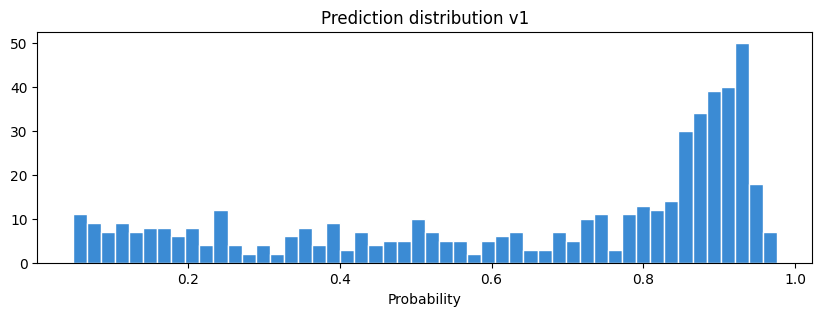

In [10]:
test_df = pd.read_csv(CFG['sample_sub'])[['id']].rename(columns={'id':'image'})
print(f'Test samples: {len(test_df)}')

final_preds = run_inference(test_df, tag='')
v1_path = save_submission(test_df, final_preds, 'submission_v1.csv')

plt.figure(figsize=(10,3))
plt.hist(final_preds, bins=50, color='#3B8BD4', edgecolor='white')
plt.title('Prediction distribution v1'); plt.xlabel('Probability'); plt.show()

## 🔄 CELL 10 — Pseudo Round 1


  PSEUDO LABELING ROUND 1
  Confident: 16/509 (mask=14, no-mask=2)
  Combined: 1324 (1308 orig + 16 pseudo)

  Retraining efficientnet_b2_pseudo1...
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b2_pseudo1 — Overall OOF AUC: 0.50000

  Retraining efficientnet_b4_pseudo1...
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b4_pseudo1 — Overall OOF AUC: 0.50000
  efficientnet_b2_pseudo1  OOF AUC = 0.99843
  efficientnet_b4_pseudo1  OOF AUC = 0.99873
  Equal weight AUC: 0.99893
  Optimised AUC:    0.99893
    efficientnet_b2_pseudo1: 0.4886
    efficientnet_b4_pseudo1: 0.5114

efficientnet_b2_pseudo1 — 5 folds  weight=0.4886
  efficientnet_b2_pseudo1_fold1.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
  efficientnet_b2_pseud

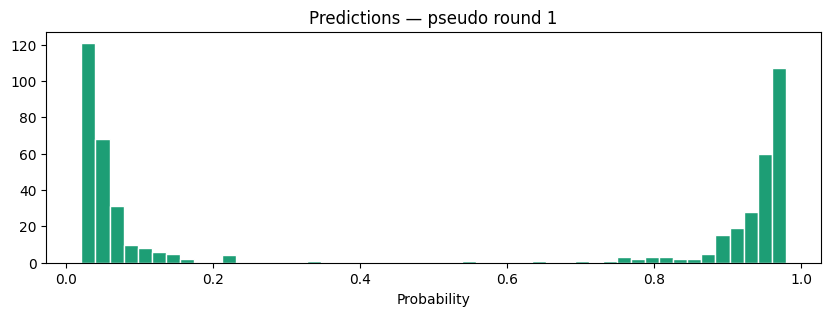

In [11]:
v1_path = get_sub_path('submission_v1.csv')
r1_path, r1_preds = run_pseudo_round(round_num=1, base_sub_path=v1_path)

## 🔄 CELL 11 — Pseudo Round 2


  PSEUDO LABELING ROUND 2
  Confident: 312/509 (mask=143, no-mask=169)
  Combined: 1620 (1308 orig + 312 pseudo)

  Retraining efficientnet_b2_pseudo2...
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b2_pseudo2 — Overall OOF AUC: 0.91306

  Retraining efficientnet_b4_pseudo2...
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b4_pseudo2 — Overall OOF AUC: 0.91280
  efficientnet_b2_pseudo2  OOF AUC = 0.99958
  efficientnet_b4_pseudo2  OOF AUC = 0.81986
  Equal weight AUC: 0.99708
  Optimised AUC:    0.99958
    efficientnet_b2_pseudo2: 1.0000
    efficientnet_b4_pseudo2: 0.0000

efficientnet_b2_pseudo2 — 5 folds  weight=1.0000
  efficientnet_b2_pseudo2_fold1.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
  efficientnet_b2_

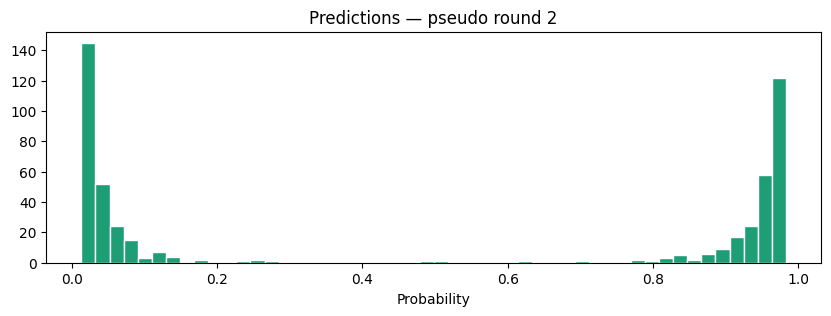

In [12]:
r1_path = get_sub_path('submission_pseudo_r1.csv')
r2_path, r2_preds = run_pseudo_round(round_num=2, base_sub_path=r1_path)

## 🔄 CELL 12 — Pseudo Round 3


  PSEUDO LABELING ROUND 3
  Confident: 364/509 (mask=167, no-mask=197)
  Combined: 1672 (1308 orig + 364 pseudo)

  Retraining efficientnet_b2_pseudo3...
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b2_pseudo3 — Overall OOF AUC: 0.50000

  Retraining efficientnet_b4_pseudo3...
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b4_pseudo3 — Overall OOF AUC: 0.50000
  efficientnet_b2_pseudo3  OOF AUC = 0.99911
  efficientnet_b4_pseudo3  OOF AUC = 0.99864
  ⚠️ OOF size mismatch [1673, 1674] — using equal weights

efficientnet_b2_pseudo3 — 5 folds  weight=0.5000
  efficientnet_b2_pseudo3_fold1.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
  efficientnet_b2_pseudo3_fold2.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 d

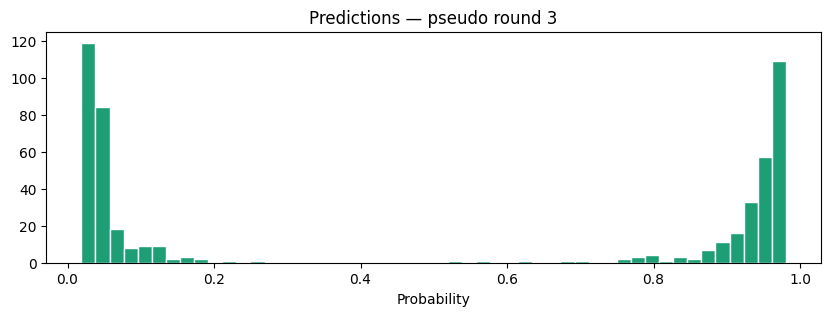

In [13]:
r2_path = get_sub_path('submission_pseudo_r2.csv')
r3_path, r3_preds = run_pseudo_round(round_num=3, base_sub_path=r2_path)

## 🔄 CELL 13 — Pseudo Round 4 (and beyond)


  PSEUDO LABELING ROUND 4
  Confident: 331/509 (mask=152, no-mask=179)
  Combined: 1639 (1308 orig + 331 pseudo)

  Retraining efficientnet_b2_pseudo4...
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b2_pseudo4 — Overall OOF AUC: 0.50000

  Retraining efficientnet_b4_pseudo4...
Resuming — folds done: [1, 2, 3, 4, 5]
Fold 1 ✓ (already done)
Fold 2 ✓ (already done)
Fold 3 ✓ (already done)
Fold 4 ✓ (already done)
Fold 5 ✓ (already done)

  efficientnet_b4_pseudo4 — Overall OOF AUC: 0.50000
  efficientnet_b2_pseudo4  OOF AUC = 0.99889
  efficientnet_b4_pseudo4  OOF AUC = 0.99850
  Equal weight AUC: 0.99901
  Optimised AUC:    0.99901
    efficientnet_b2_pseudo4: 0.4979
    efficientnet_b4_pseudo4: 0.5021

efficientnet_b2_pseudo4 — 5 folds  weight=0.4979
  efficientnet_b2_pseudo4_fold1.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
  efficientnet_b2_

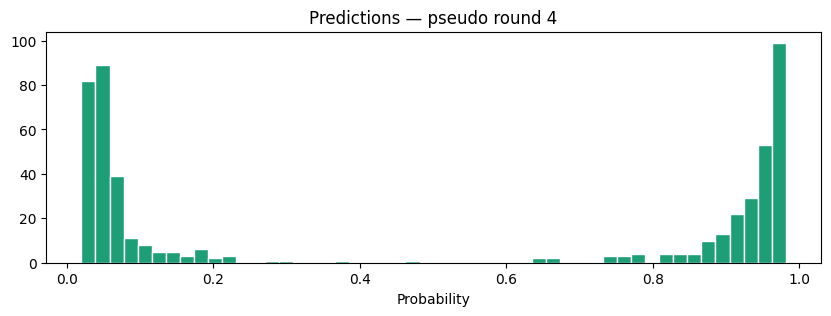

In [14]:
r3_path = get_sub_path('submission_pseudo_r3.csv')
r4_path, r4_preds = run_pseudo_round(round_num=4, base_sub_path=r3_path)

In [ ]:
r4_path = get_sub_path('submission_pseudo_r4.csv')
r5_path, r5_preds = run_pseudo_round(round_num=5, base_sub_path=r4_path)


  PSEUDO LABELING ROUND 5
  Confident: 285/509 (mask=141, no-mask=144)
  Combined: 1593 (1308 orig + 285 pseudo)

  Retraining efficientnet_b2_pseudo5...

  efficientnet_b2_pseudo5  ·  Fold 1/5


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

  Built efficientnet_b2 | features=1408
  Ep 01/40 | loss=0.6599 auc=0.7159 | val_loss=0.5541 val_auc=0.9659 | 346s
  ✓ Best val_auc=0.96589 saved (31.3MB)
  Ep 02/40 | loss=0.4082 auc=0.9709 | val_loss=0.1793 val_auc=0.9981 | 26s
  ✓ Best val_auc=0.99807 saved (31.3MB)


## 📥 CELL 14 — Download Best Submission

In [ ]:
from google.colab import files
from pathlib import Path

# Auto-pick the latest pseudo round submission
sub_dir = Path(CFG['sub_dir'])
all_subs = sorted(sub_dir.glob('submission_pseudo_r*.csv'))

if all_subs:
    best = all_subs[-1]
    print(f'Downloading: {best.name}')
    files.download(str(best))
else:
    best = sub_dir / 'submission_v1.csv'
    print(f'No pseudo submissions found, downloading v1')
    files.download(str(best))

# Show all available submissions
print('\nAll submissions:')
for f in sorted(sub_dir.glob('submission_*.csv')):
    df = pd.read_csv(f)
    conf = ((df['label']>=0.95)|(df['label']<=0.05)).sum()
    print(f'  {f.name:<40} mean={df["label"].mean():.4f}  confident={conf}/{len(df)}')

Downloading: submission_pseudo_r4.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All submissions:
  submission_ensemble.csv                  mean=0.4840  confident=131/509
  submission_pseudo_r1.csv                 mean=0.4925  confident=312/509
  submission_pseudo_r2.csv                 mean=0.4911  confident=366/509
  submission_pseudo_r3.csv                 mean=0.4909  confident=327/509
  submission_pseudo_r4.csv                 mean=0.4931  confident=285/509
  submission_v1.csv                        mean=0.6513  confident=17/509


## 🛠️ CELL 15 — Utilities

In [ ]:
# GPU status
!nvidia-smi

# Disk usage
!df -h .

# List all checkpoints
print('\nCheckpoints:')
for f in sorted(Path(CFG['model_dir']).glob('*.pt')):
    print(f'  {f.name:<50}  {f.stat().st_size/1e6:.0f}MB')

# OOF AUCs
print('\nOOF scores:')
for f in sorted(Path(CFG['model_dir']).glob('*_oof.csv')):
    df = pd.read_csv(f)
    auc = compute_auc(df['target'].values, df['oof_pred'].values)
    print(f'  {f.name:<50}  AUC={auc:.5f}')

Tue Mar 24 03:55:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             30W /   70W |     301MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Generate b2-only submission using all 5 fold checkpoints
from pathlib import Path

tag = '_pseudo2'  # or whichever round had the best b2 performance
test_df = pd.read_csv(CFG['sample_sub'])[['id']].rename(columns={'id':'image'})

model_dir = Path(CFG['model_dir'])
fold_preds = []

for ckpt in sorted(model_dir.glob(f'efficientnet_b2{tag}_fold*.pt')):
    print(f'Loading {ckpt.name}')
    m = MaskNet('efficientnet_b2', pretrained=False, dropout=0.35).to(DEVICE)
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    fold_preds.append(predict_tta(m, test_df, CFG['images_dir'], 300))
    del m; flush()

final_preds = np.mean(fold_preds, axis=0)
b2_path = save_submission(test_df, final_preds, 'submission_b2_only.csv')

from google.colab import files
files.download('outputs/submissions/submission_b2_only.csv')

Loading efficientnet_b2_pseudo2_fold1.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
Loading efficientnet_b2_pseudo2_fold2.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
Loading efficientnet_b2_pseudo2_fold3.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
Loading efficientnet_b2_pseudo2_fold4.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
Loading efficientnet_b2_pseudo2_fold5.pt
  Built efficientnet_b2 | features=1408
    TTA 8/8 done
✅ Saved: outputs/submissions/submission_b2_only.csv
   shape=509  min=0.0131  max=0.9827  mean=0.4912


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>